
Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  i

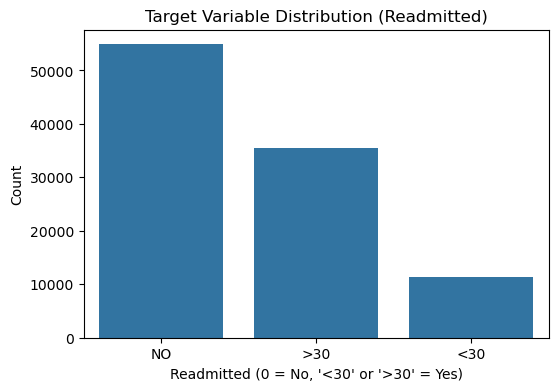

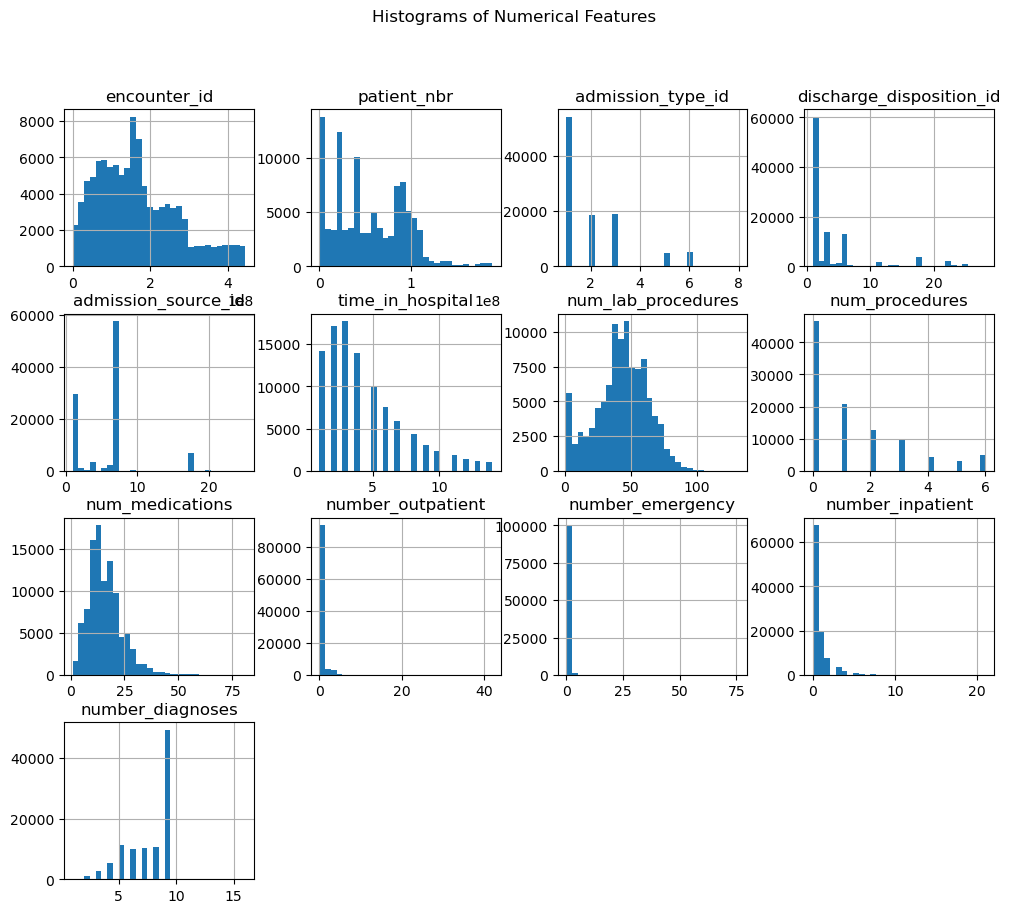

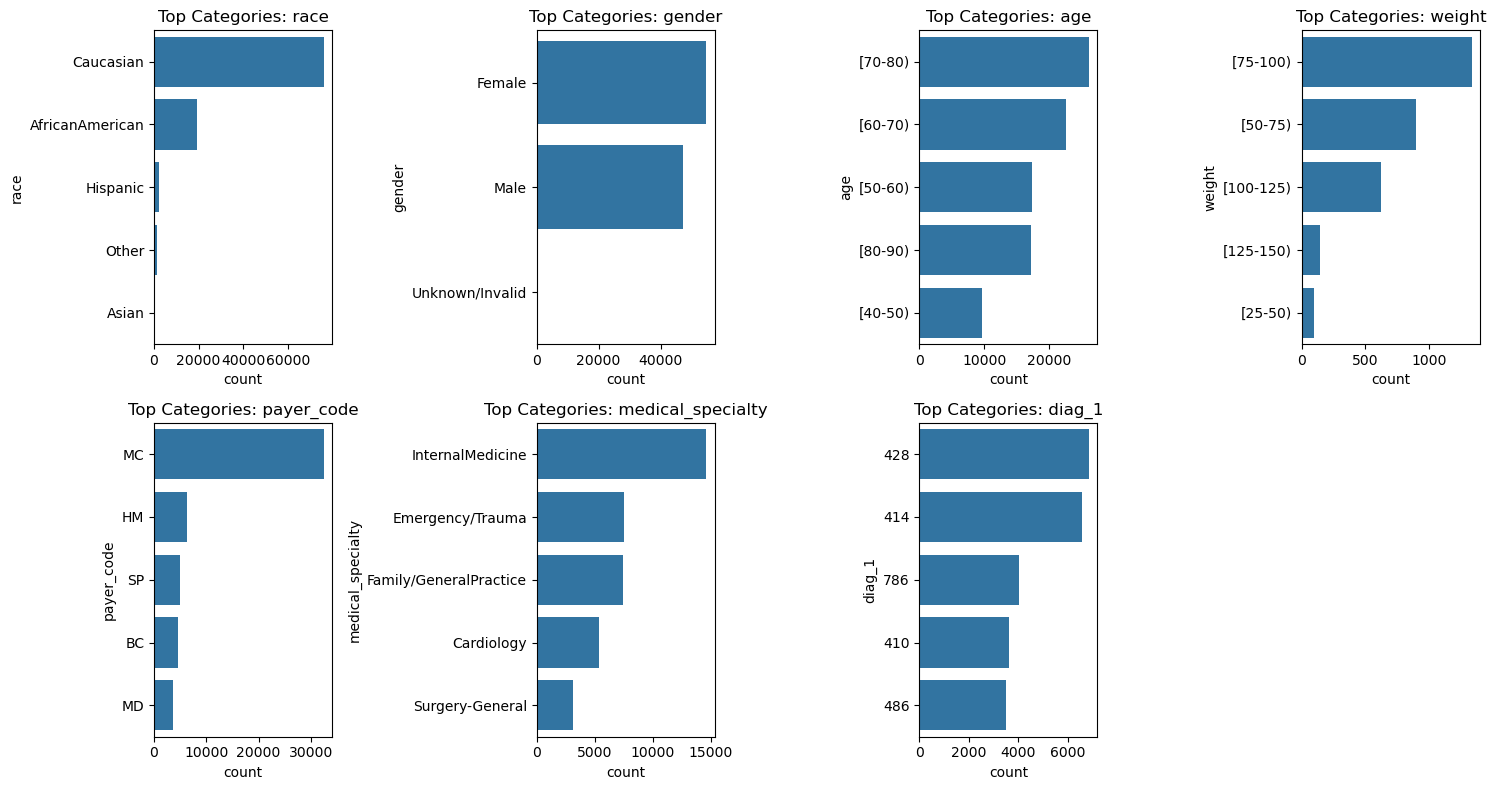

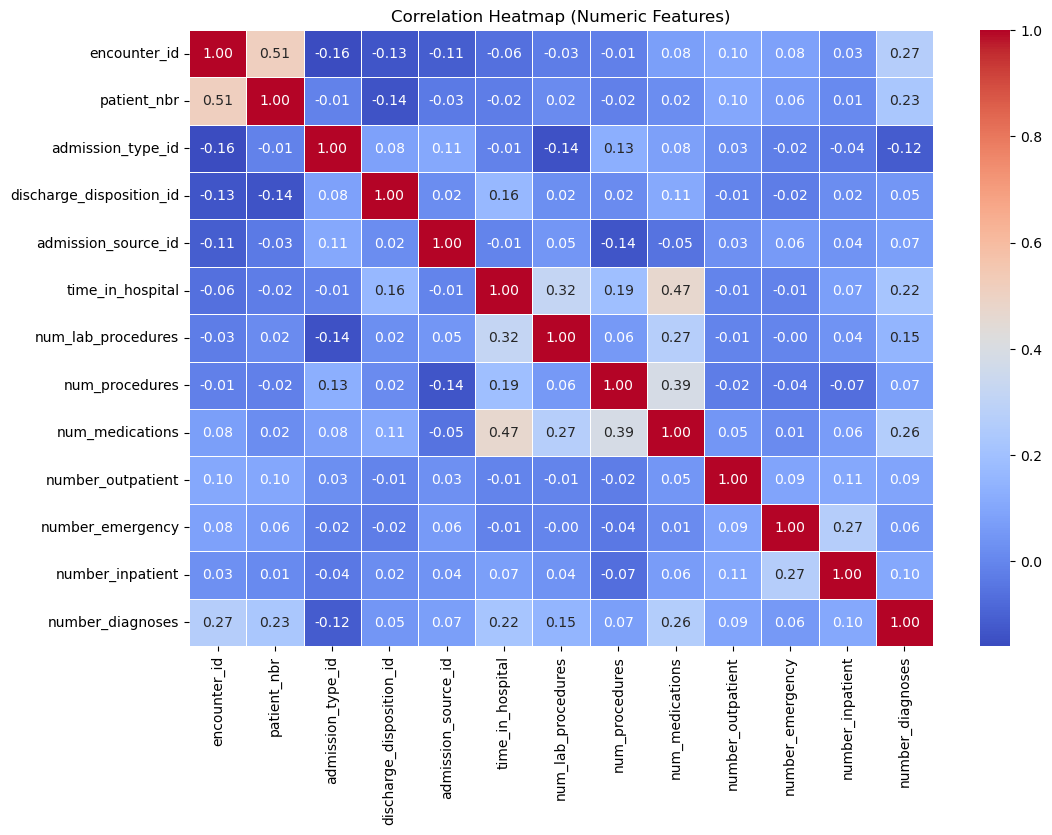

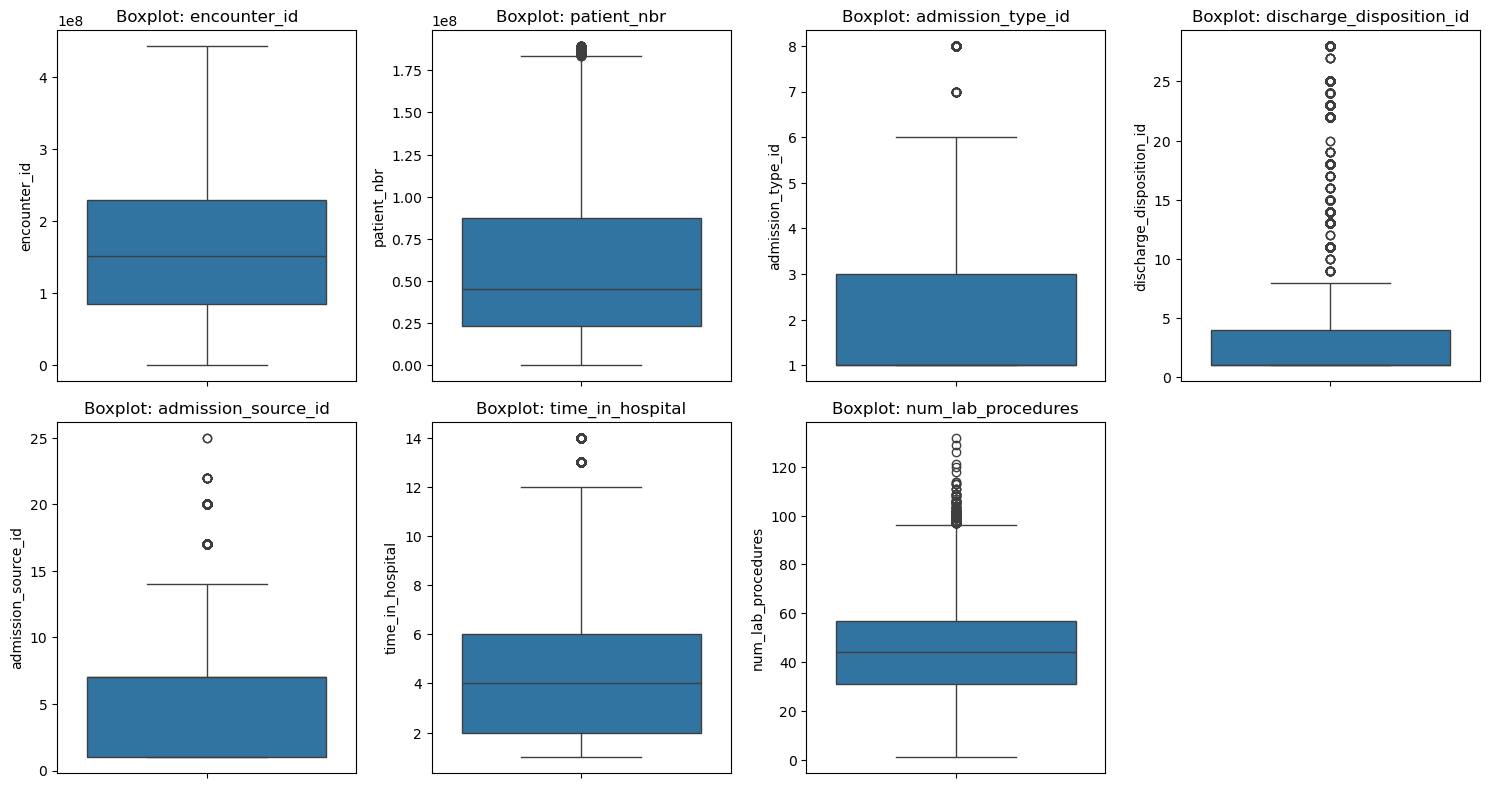

C:\Users\TE524618\AppData\Local\Temp\ipykernel_11052\2657851515.py:85: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)



Class Distribution Before Sampling:
readmitted
0    54864
1    46902
Name: count, dtype: int64

Class Distribution After Sampling:
readmitted
0    25000
1    25000
Name: count, dtype: int64

Selected Top 20 Features:
 Index(['encounter_id', 'patient_nbr', 'admission_type_id',
       'discharge_disposition_id', 'number_outpatient', 'number_emergency',
       'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses',
       'max_glu_serum', 'metformin', 'repaglinide', 'nateglinide', 'acarbose',
       'miglitol', 'glyburide-metformin', 'change', 'diabetesMed'],
      dtype='object')

Class Distribution After Splitting:
Train Set:
 readmitted
1    20000
0    20000
Name: count, dtype: int64
Test Set:
 readmitted
0    5000
1    5000
Name: count, dtype: int64

Training Logistic Regression...


C:\Users\TE524618\AppData\Local\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(



Training Random Forest...

Training Gradient Boosting...

Training XGBoost...

Model Comparison:
                      Accuracy  Precision  Recall  F1-Score
Logistic Regression    0.6194   0.639161  0.5484  0.590312
Random Forest          0.7099   0.711295  0.7066  0.708940
Gradient Boosting      0.6244   0.634110  0.5882  0.610293
XGBoost                0.6717   0.670439  0.6754  0.672910


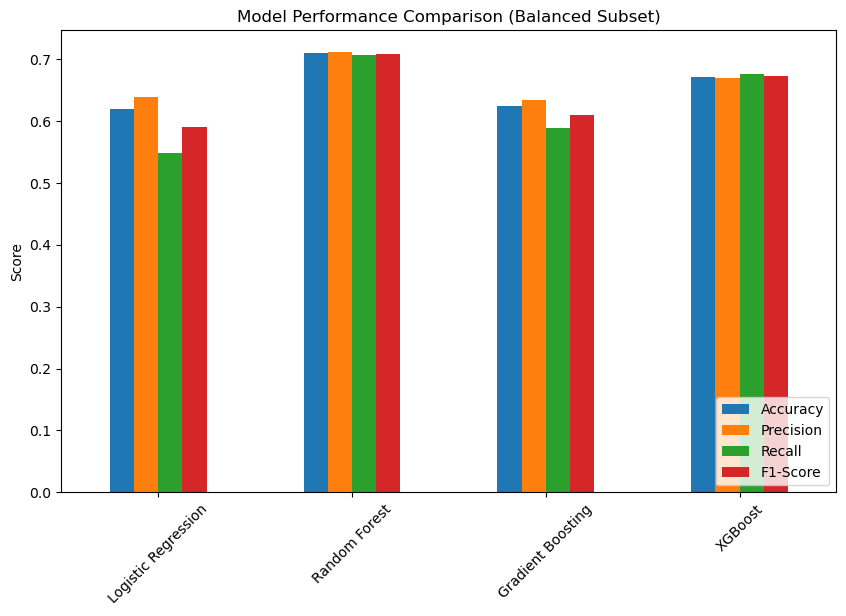

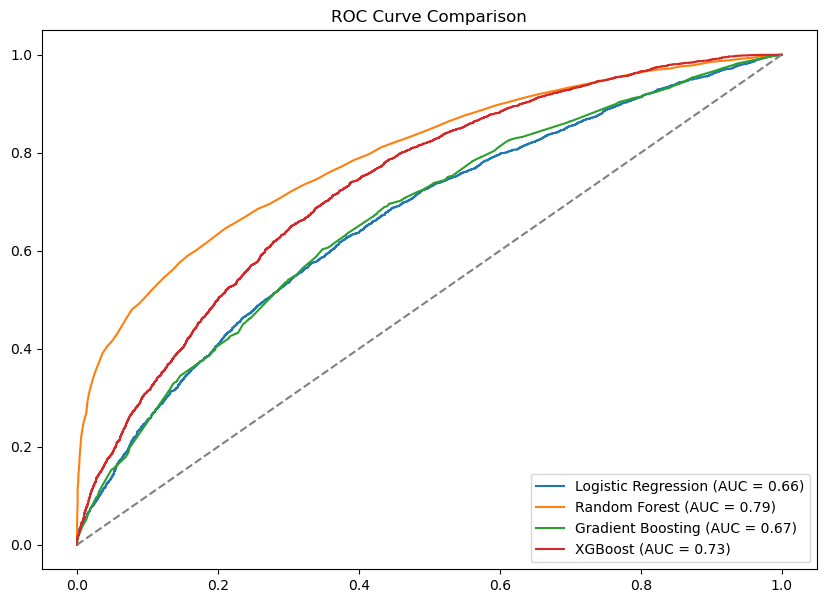

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedShuffleSplit, train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from xgboost import XGBClassifier
from sklearn.metrics import roc_curve, auc

# ==============================
# Step 1: Load Data
# ==============================
diabetes_file = "./diabetes+130-us+hospitals+for+years+1999-2008/diabetic_data.csv"
df = pd.read_csv(diabetes_file)

# ==============================
# Step 2: Exploratory Data Analysis (EDA)
# ==============================

# Overview of dataset
print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nUnique Values per Column:")
print(df.nunique())

print("\nDataset Shape:", df.shape)

# Convert '?' to NaN for missing value handling
df = df.replace("?", np.nan)

# Target Variable Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x=df["readmitted"])
plt.title("Target Variable Distribution (Readmitted)")
plt.xlabel("Readmitted (0 = No, '<30' or '>30' = Yes)")
plt.ylabel("Count")
plt.show()

# Numerical Feature Distributions
numeric_columns = df.select_dtypes(include=["int64", "float64"]).columns
df[numeric_columns].hist(figsize=(12, 10), bins=30)
plt.suptitle("Histograms of Numerical Features")
plt.show()

# Categorical Feature Distributions (Top 5 Categories)
categorical_columns = df.select_dtypes(include=["object"]).columns
plt.figure(figsize=(15, 8))
for i, col in enumerate(categorical_columns[:7], 1):  # Limit to first 7 for visualization
    plt.subplot(2, 4, i)
    sns.countplot(y=df[col], order=df[col].value_counts().index[:5])  # Show top 5 categories
    plt.title(f"Top Categories: {col}")
plt.tight_layout()
plt.show()

# Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df[numeric_columns].corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()

# Boxplots for Outliers (Numeric Variables)
plt.figure(figsize=(15, 8))
for i, col in enumerate(numeric_columns[:7], 1):  # Limit to first 7
    plt.subplot(2, 4, i)
    sns.boxplot(y=df[col])
    plt.title(f"Boxplot: {col}")
plt.tight_layout()
plt.show()

# ==============================
# Step 3: Handle Missing Values
# ==============================

# Fill categorical columns with mode
for col in categorical_columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Fill numeric columns with median
df[numeric_columns] = df[numeric_columns].fillna(df[numeric_columns].median())

# Remove duplicate entries
df.drop_duplicates(inplace=True)

# Convert `readmitted` to binary (1 = "<30" or ">30", 0 = "NO")
df["readmitted"] = df["readmitted"].apply(lambda x: 1 if x in ["<30", ">30"] else 0)

# Print class distribution before sampling
print("\nClass Distribution Before Sampling:")
print(df["readmitted"].value_counts())



# ==============================
# Step 4: Balanced Subset Sampling (40,000 records)
# ==============================

df_0 = df[df["readmitted"] == 0].sample(n=25000, random_state=42, replace=False)
df_1 = df[df["readmitted"] == 1].sample(n=25000, random_state=42, replace=True)

df = pd.concat([df_0, df_1], axis=0).reset_index(drop=True)

# Confirm balanced distribution
print("\nClass Distribution After Sampling:")
print(df["readmitted"].value_counts())

# ==============================
# Step 5: Encode Categorical Variables
# ==============================

encoder = LabelEncoder()
for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col])

# ==============================
# Step 6: Standardize Numberical Columns
# ==============================


# Scale numeric columns
scaler = StandardScaler()
df[numeric_columns] = scaler.fit_transform(df[numeric_columns])

# ==============================
# Step 7: Feature Selection
# ==============================

X = df.drop(columns=["readmitted"])
y = df["readmitted"]

# Select top K best features
k = min(20, X.shape[1])  # Select top 20 or fewer if dataset has fewer columns
selector = SelectKBest(score_func=mutual_info_classif, k=k)
X_selected = selector.fit_transform(X, y)

# Get selected feature names
selected_features = X.columns[selector.get_support()]
print(f"\nSelected Top {k} Features:\n", selected_features)

# ==============================
# Step 8: Train-Test Split (Stratified)
# ==============================

stratified_split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in stratified_split.split(X_selected, y):
    X_train, X_test = X_selected[train_index], X_selected[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

print("\nClass Distribution After Splitting:")
print("Train Set:\n", y_train.value_counts())
print("Test Set:\n", y_test.value_counts())

# ==============================
# Step 9: Train and Compare Models
# ==============================

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, solver="saga"),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=10, random_state=42),
    "XGBoost": XGBClassifier(eval_metric="logloss", random_state=42)
}

results = {}

for model_name, model in models.items():
    print(f"\nTraining {model_name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Evaluate model
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)

    results[model_name] = {
        "Accuracy": accuracy,
        "Precision": report["1"]["precision"],
        "Recall": report["1"]["recall"],
        "F1-Score": report["1"]["f1-score"]
    }

# ==============================
# Step 10: Model Comparison
# ==============================

results_df = pd.DataFrame(results).T
print("\nModel Comparison:\n", results_df)

# Plot results
results_df.plot(kind="bar", figsize=(10, 6))
plt.title("Model Performance Comparison (Balanced Subset)")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend(loc="lower right")
plt.show()

# Plot ROC Curve
plt.figure(figsize=(10, 7))
for model_name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_probs = model.predict_proba(X_test)[:, 1]
    else:
        y_probs = model.decision_function(X_test)

    fpr, tpr, _ = roc_curve(y_test, y_probs)
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {auc(fpr, tpr):.2f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.show()
